# 📊 Exploratory Data Analysis and Visualization

### 👩‍🎓 Student Details:
- **Name:** Mounika  
- **Roll Number:** 160123733024


## Data Loading and Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("netflix_titles.csv")

# Convert date_added
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract year added
df['year_added'] = df['date_added'].dt.year

# Extract duration properly
df['duration_mins'] = np.where(
    df['type'] == 'Movie',
    df['duration'].str.extract(r'(\d+)').astype(float),
    np.nan
)

# Extract seasons properly
df['season_count'] = np.where(
    df['type'] == 'TV Show',
    df['duration'].str.extract(r'(\d+)').astype(float),
    np.nan
)

# Clean country column
df['country'] = df['country'].fillna('Unknown').apply(lambda x: x.split(',')[0])

### Q1. Create a line plot showing the number of titles added to Netflix per year for Movies and TV Shows separately. Discuss the trend in content strategy over time.

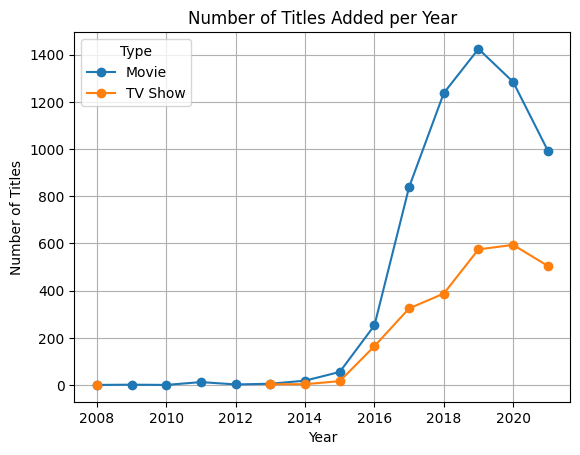

In [2]:
# Group data by year and type
data = df.groupby(['year_added', 'type']).size().unstack()

# Plot line graph
data.plot(kind='line', marker='o')

plt.title("Number of Titles Added per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.legend(title="Type")
plt.grid(True)

plt.show()

### Observation:

- Netflix content additions increased significantly after 2015.
- Movies dominate the platform, showing higher numbers compared to TV Shows.
- TV Shows show a steady growth, especially in recent years.
- This indicates Netflix's shift towards original series and binge-worthy content.
- The sharp rise suggests aggressive expansion and content acquisition strategy.

### Q2. Generate a scatter plot of content release year vs. the year added to Netflix. Color points by content type (Movie/TV Show). Identify any time lag patterns.

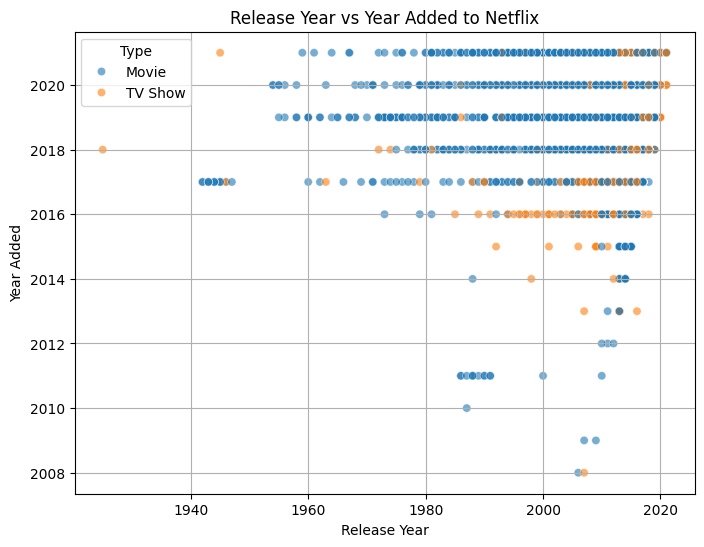

In [3]:
# Remove missing values for accurate plotting
data = df.dropna(subset=['release_year', 'year_added'])

# Scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=data,
    x='release_year',
    y='year_added',
    hue='type',
    alpha=0.6
)

plt.title("Release Year vs Year Added to Netflix")
plt.xlabel("Release Year")
plt.ylabel("Year Added")
plt.legend(title="Type")
plt.grid(True)

plt.show()

### Observation:

- Most content lies close to the diagonal, indicating that it is added to Netflix soon after release.
- Older movies show a larger gap between release year and year added.
- TV Shows generally have smaller delays compared to Movies.
- Netflix also adds older content to expand its library, especially films released before 2000.
- This suggests a mix of both new releases and archived content acquisition strategy.

### Q3. Visualize the distribution of movie durations using a histogram with binning. Compare short, medium, and long movies. Overlay a KDE curve.

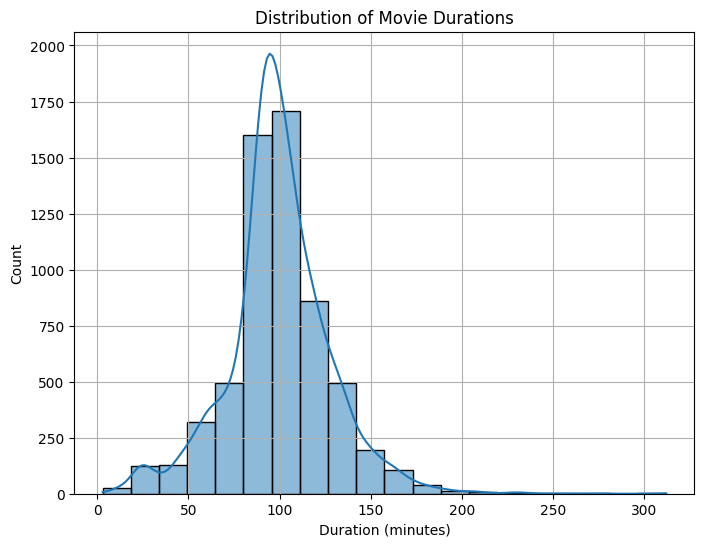

In [4]:
# Create duration column (VERY IMPORTANT)
df['duration_mins'] = df['duration'].str.extract(r'(\d+)').astype(float)
# Filter only Movies
movies = df[df['type'] == 'Movie']

# Remove missing duration values
movies = movies.dropna(subset=['duration_mins'])

# Plot histogram with KDE
plt.figure(figsize=(8,6))
sns.histplot(
    movies['duration_mins'],
    bins=20,
    kde=True
)

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")

plt.grid(True)
plt.show()

### Observation:

- Most movies fall in the range of 80–120 minutes (medium length).
- Very short movies (<60 mins) are relatively fewer.
- Very long movies (>150 mins) are also rare.
- The distribution is slightly right-skewed, indicating some longer movies.
- The KDE curve shows a peak around 90–100 minutes, which is the most common duration.

### Q4. Create a density plot (KDE) showing the number of seasons for TV Shows. Identify the most common season count and discuss the implication for content production.

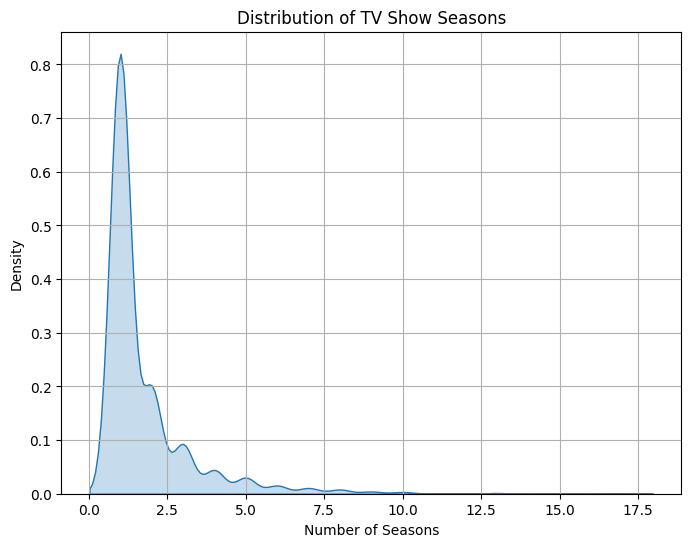

In [12]:
df['season_count'] = df['duration'].str.extract(r'(\d+)').astype(float)
# Filter only TV Shows
tv = df[df['type'] == 'TV Show']

# Remove missing values
tv = tv.dropna(subset=['season_count'])

# Plot KDE
plt.figure(figsize=(8,6))
sns.kdeplot(tv['season_count'], fill=True)

plt.title("Distribution of TV Show Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Density")

plt.grid(True)
plt.show()

### Observation:

- Most TV Shows have 1–2 seasons.
- Very few shows extend beyond 5 seasons.
- The distribution is heavily right-skewed.
- Peak is around 1 season.

### Q5. Use Seaborn's countplot to show the distribution of content ratings (e.g., TV-MA, PG-13). Create subplots comparing rating distribution for Movies vs. TV Shows.

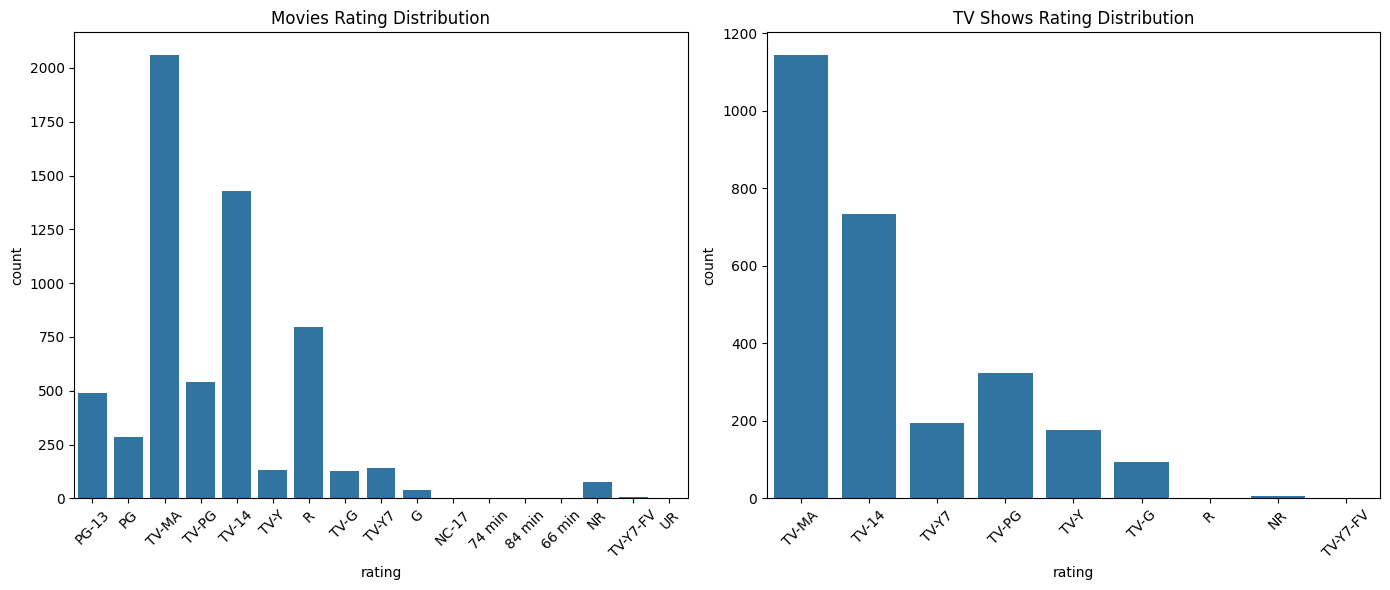

In [13]:
# Create subsets
movies = df[df['type'] == 'Movie']
tv = df[df['type'] == 'TV Show']

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Movies plot
sns.countplot(data=movies, x='rating', ax=axes[0])
axes[0].set_title("Movies Rating Distribution")
axes[0].tick_params(axis='x', rotation=45)

# TV Shows plot
sns.countplot(data=tv, x='rating', ax=axes[1])
axes[1].set_title("TV Shows Rating Distribution")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Observation:

- TV-MA is the most common rating for both Movies and TV Shows.
- Movies have a wider variety of ratings (PG, PG-13, R, etc.).
- TV Shows are more concentrated in fewer rating categories.
- Family-friendly ratings (like G or PG) are less frequent.


### Q6. Create a contour/density plot of release year vs. year added for movies. Use plt.contourf and identify the typical delay between a film's release and its Netflix addition.

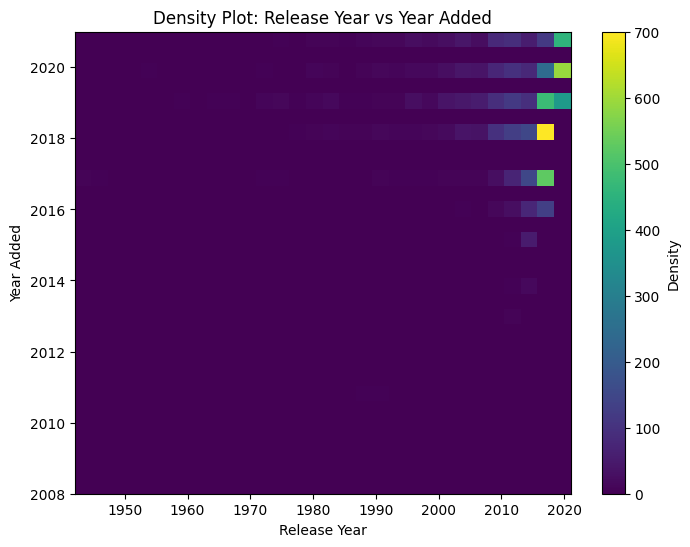

In [14]:
# Filter Movies only
movies = df[df['type'] == 'Movie']

# Remove missing values
movies = movies.dropna(subset=['release_year', 'year_added'])

# Create bins
x = movies['release_year']
y = movies['year_added']

# Create 2D histogram (density)
plt.figure(figsize=(8,6))
plt.hist2d(x, y, bins=30)

plt.colorbar(label='Density')

plt.title("Density Plot: Release Year vs Year Added")
plt.xlabel("Release Year")
plt.ylabel("Year Added")

plt.show()

### Observation:

- Highest density is near the diagonal line.
- This means most movies are added within a short time after release.
- Typical delay is around 1–3 years.
- Older movies show larger delays before being added.
- Netflix tends to acquire recent movies quickly while also adding older films to expand its library.

### Q7. Build a 2x2 subplot grid:
(a) bar chart of top 10 countries by content count  
(b) pie chart of content type distribution  
(c) histogram of release years  
(d) boxplot of duration by type

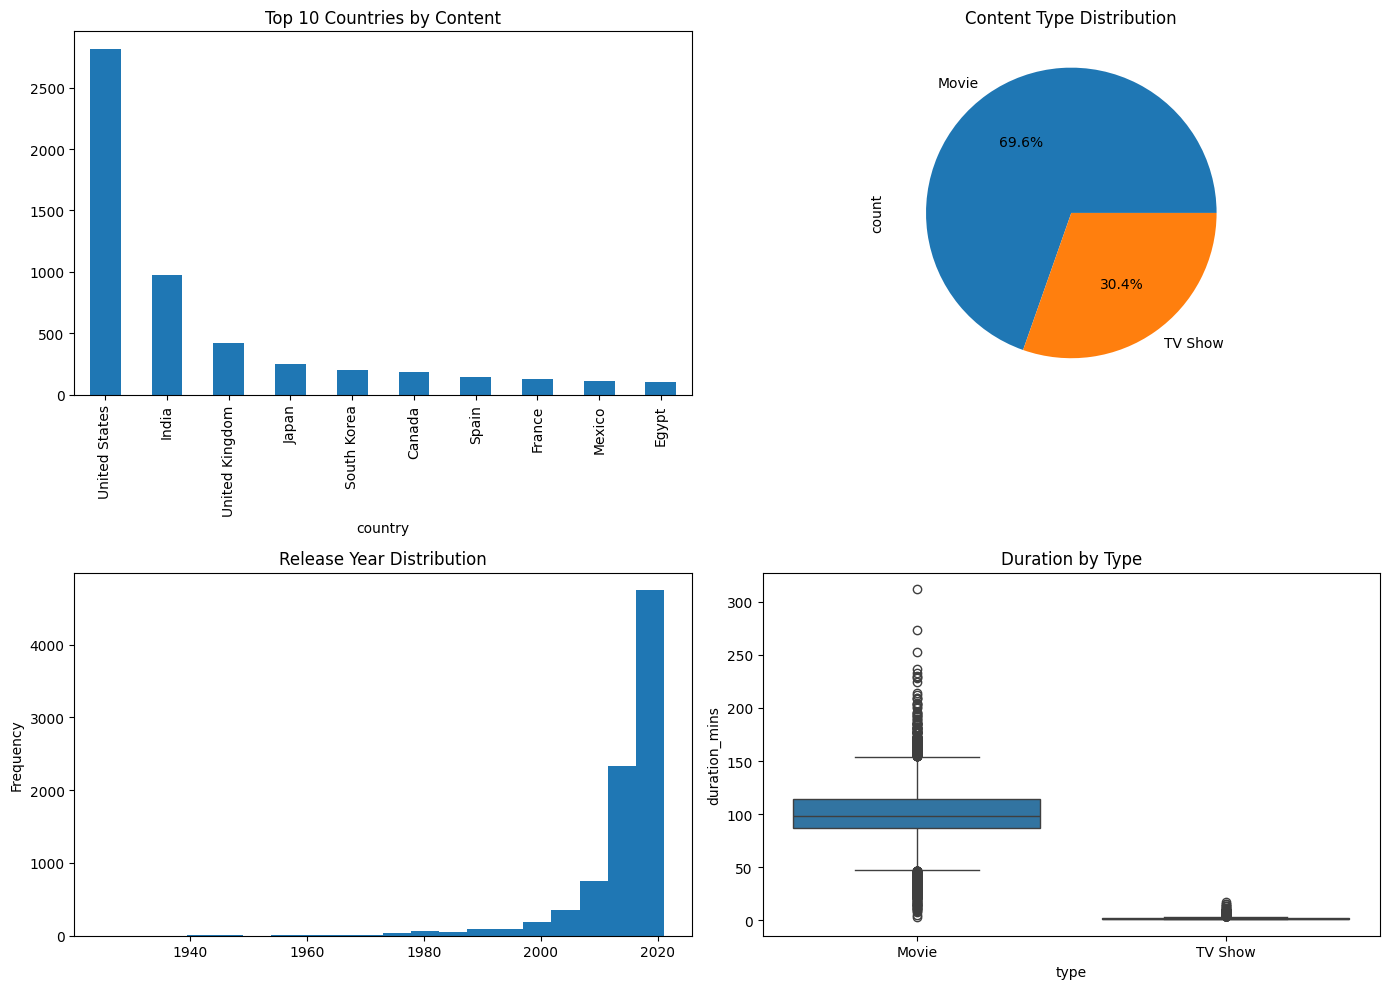

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# (a) Top 10 countries
df['country'].value_counts().head(10).plot(
    kind='bar', ax=axes[0,0]
)
axes[0,0].set_title("Top 10 Countries by Content")

# (b) Pie chart for type
df['type'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', ax=axes[0,1]
)
axes[0,1].set_title("Content Type Distribution")

# (c) Histogram of release years
df['release_year'].plot(
    kind='hist', bins=20, ax=axes[1,0]
)
axes[1,0].set_title("Release Year Distribution")

# (d) Boxplot of duration by type
sns.boxplot(data=df, x='type', y='duration_mins', ax=axes[1,1])
axes[1,1].set_title("Duration by Type")

plt.tight_layout()
plt.show()

### Observation:

- (a) USA is the top contributor, followed by India and UK.
- (b) Movies make up a larger portion compared to TV Shows.
- (c) Most content is released after 2000, showing modern dominance.
- (d) Movies have a wide range of durations, while TV Shows show less variation.

### Q8. Use error bars to visualize average movie duration per rating category (with standard deviation). Determine which rating category shows the most duration variability.

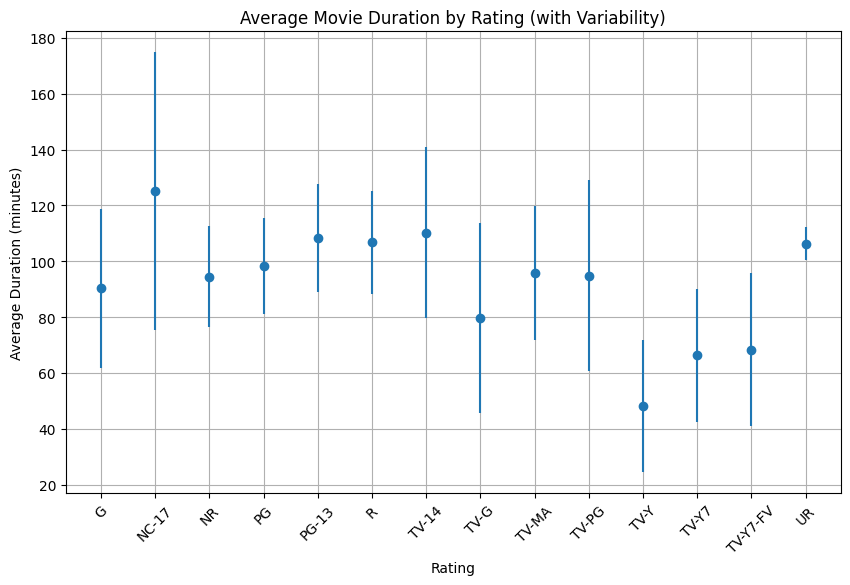

In [16]:
# Filter only Movies
movies = df[df['type'] == 'Movie']

# Remove missing values
movies = movies.dropna(subset=['duration_mins', 'rating'])

# Group by rating
group = movies.groupby('rating')['duration_mins']

mean = group.mean()
std = group.std()

# Plot error bars
plt.figure(figsize=(10,6))
plt.errorbar(mean.index, mean, yerr=std, fmt='o')

plt.title("Average Movie Duration by Rating (with Variability)")
plt.xlabel("Rating")
plt.ylabel("Average Duration (minutes)")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Observation:

- Ratings like TV-MA and R have higher average durations.
- Some categories show larger error bars, indicating high variability.
- Categories like PG or G have smaller variability.

### Q9. Create a Seaborn heatmap showing content count by country (top 10) and year (2015–2021). Use annotations and a diverging palette to identify growth patterns.

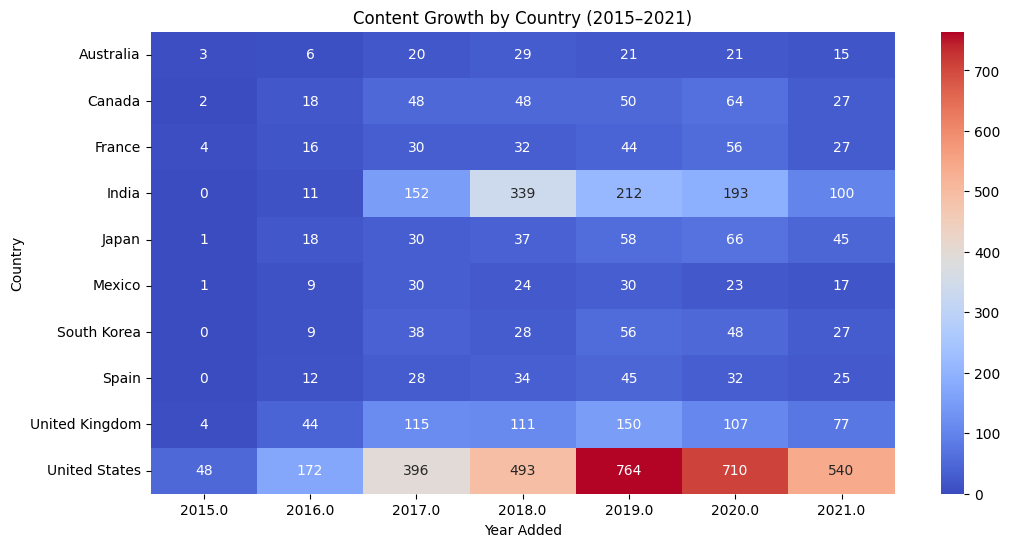

In [17]:
# Clean country column (take first country if multiple)
df['country'] = df['country'].dropna().apply(lambda x: x.split(',')[0])

# Get top 10 countries
top_countries = df['country'].value_counts().head(10).index

# Filter data
heat_data = df[df['country'].isin(top_countries)]

# Filter years (2015–2021)
heat_data = heat_data[(heat_data['year_added'] >= 2015) & (heat_data['year_added'] <= 2021)]

# Create pivot table
pivot = heat_data.groupby(['country', 'year_added']).size().unstack(fill_value=0)

# Plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(
    pivot,
    annot=True,
    fmt='d',
    cmap='coolwarm'
)

plt.title("Content Growth by Country (2015–2021)")
plt.xlabel("Year Added")
plt.ylabel("Country")

plt.show()

### Observation:

- Content production increased significantly from 2017 to 2020.
- USA shows the highest contribution across all years.
- India shows rapid growth in recent years.
- Some countries show sudden spikes, indicating expansion phases.

### Q10. Use Seaborn's FacetGrid or pairplot on a derived numeric DataFrame (year, duration_mins, season_count) grouped by type. Discuss multivariate patterns.

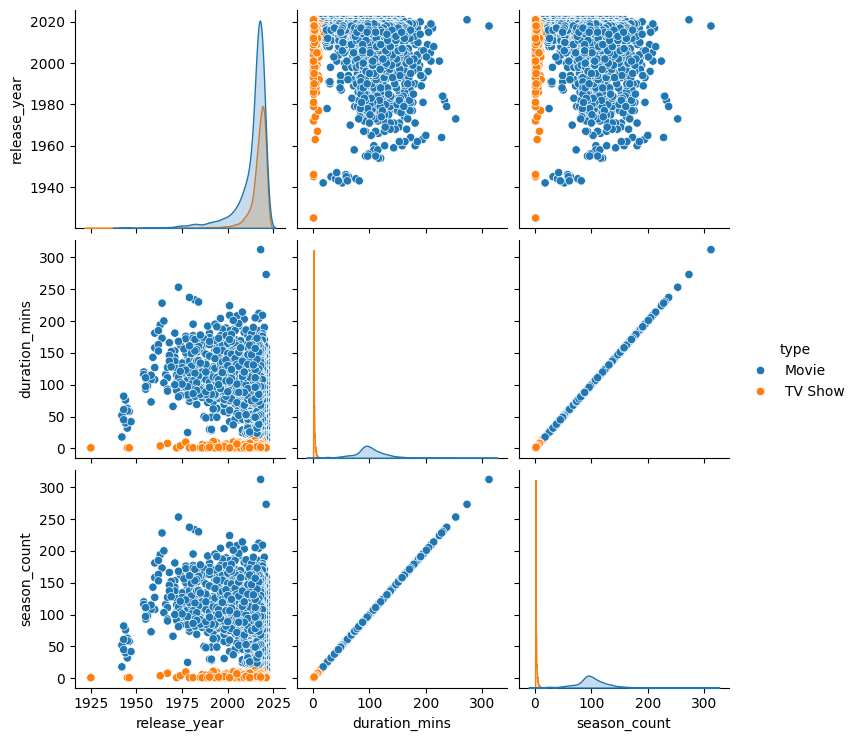

In [19]:
# Prepare data (only needed columns)
data = df[['type', 'release_year', 'duration_mins', 'season_count']].copy()

# Drop missing values
data = data.dropna()

# Pairplot
sns.pairplot(data, hue='type')

plt.show()

### Observation:

- Movies show a wide spread in duration compared to TV Shows.
- TV Shows cluster around lower season counts (mostly 1–3 seasons).
- Release year trends show more recent content across both types.
- There is no strong correlation between duration and release year.

## Final Conclusion

The exploratory data analysis of the Netflix dataset provides meaningful insights into the platform’s evolving content strategy, audience targeting, and global expansion.

A clear upward trend in content addition is observed, particularly after 2015, indicating a phase of aggressive growth and international scaling. Movies contribute the majority of content, supporting a volume-driven approach, while TV Shows demonstrate steady growth, emphasizing Netflix’s focus on long-term user engagement through episodic content.

The analysis of movie durations reveals a strong concentration around standard runtime lengths (approximately 90–110 minutes), suggesting a preference for formats that balance storytelling with viewer retention. In contrast, TV Shows are predominantly limited to 1–2 seasons, reflecting a strategic inclination toward short, binge-worthy series rather than long-running productions.

Rating distribution highlights a dominant presence of mature content (TV-MA), indicating that Netflix primarily targets adult audiences with diverse and flexible storytelling formats. Additionally, variability in duration is higher within these mature categories, suggesting greater creative freedom compared to lower-rated content.

Temporal and density-based visualizations show that most content is added to the platform within a short period after release, typically within 1–3 years. This demonstrates Netflix’s emphasis on acquiring relatively recent content while also incorporating older titles to strengthen its catalog.

Geographical analysis through heatmaps reveals significant growth across multiple countries between 2017 and 2020, with the United States maintaining a leading role and emerging markets such as India showing rapid expansion. This reflects Netflix’s global diversification strategy and increasing investment in regional content.

Overall, the visualizations collectively highlight a well-balanced strategy that combines high-volume movie additions, strategic investment in short-format TV content, and a strong focus on modern, globally diverse, and mature-oriented programming.

These insights demonstrate how data visualization techniques effectively uncover patterns, trends, and strategic decisions within large-scale entertainment datasets.